## Instagram Reach Analysis using Python

Seçtiğim proje "Instagram Reach Analysis using Python"
https://amanxai.com/2022/03/22/instagram-reach-analysis-using-python/"  

Modelde ayrıntılı data analizi yapılmış. Hangi alandan ne kadar etkilişim alınmış tek tek irdelenmiş. Modelde Kullanılan kodlar basit sade  kodlar. Yapacağım farklı bir analiz olmadığı için doğrudan model öğretmeye geçtim. Ayrıntılı data analizi için linke bakılabilir. 

Kullanılan dataset: /kaggle/input/datasets/amankumarkharwal/instagram-reach-data/Instagram data.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PassiveAggressiveRegressor

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/amankumarkharwal/instagram-reach-data/Instagram data.csv


In [3]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/amankumarkharwal/instagram-reach-data/Instagram data.csv",
    encoding="latin1"
)

df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...
3,4528,2700,621,932,73,172,10,7,213,23,8,Heres how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...
4,2518,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...


In [4]:
df.isnull().sum()

Impressions       0
From Home         0
From Hashtags     0
From Explore      0
From Other        0
Saves             0
Comments          0
Shares            0
Likes             0
Profile Visits    0
Follows           0
Caption           0
Hashtags          0
dtype: int64

Datada boş veri yok. 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Impressions     119 non-null    int64 
 1   From Home       119 non-null    int64 
 2   From Hashtags   119 non-null    int64 
 3   From Explore    119 non-null    int64 
 4   From Other      119 non-null    int64 
 5   Saves           119 non-null    int64 
 6   Comments        119 non-null    int64 
 7   Shares          119 non-null    int64 
 8   Likes           119 non-null    int64 
 9   Profile Visits  119 non-null    int64 
 10  Follows         119 non-null    int64 
 11  Caption         119 non-null    object
 12  Hashtags        119 non-null    object
dtypes: int64(11), object(2)
memory usage: 12.2+ KB


In [6]:
home = df["From Home"].sum()
hashtags = df["From Hashtags"].sum()
explore = df["From Explore"].sum()
other = df["From Other"].sum()

labels = ['From Home','From Hashtags','From Explore','Other']
values = [home, hashtags, explore, other]

fig = px.pie(df, values=values, names=labels, 
             title='Impressions on Instagram Posts From Various Sources', hole=0.5)
fig.show()

Grafikten görüldüğü gibi en çok etkileşim "From Home", gönderi  alanından, ikinci olarak da "Hashtag" lerden gelmiş. 

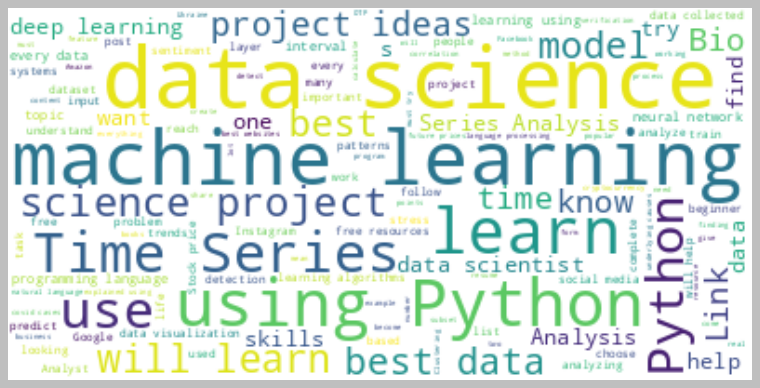

In [7]:
text = " ".join(i for i in df.Caption)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.style.use('classic')
plt.figure( figsize=(12,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

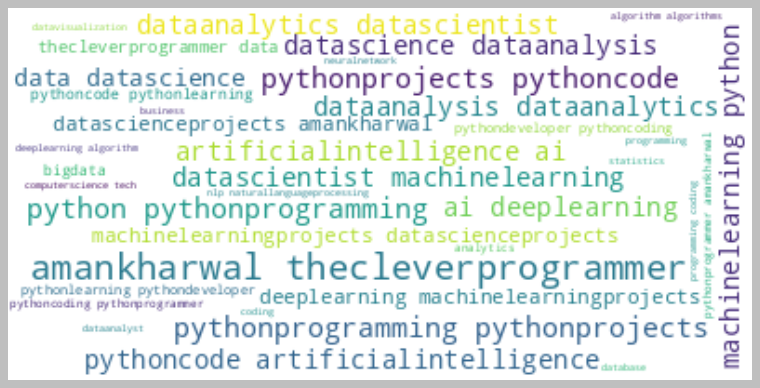

In [8]:
text = " ".join(i for i in df.Hashtags)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.figure( figsize=(12,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [9]:
df.corr(numeric_only=True)["Impressions"].sort_values(ascending=False) 

Impressions       1.000000
From Explore      0.893607
Follows           0.889363
Likes             0.849835
From Home         0.844698
Saves             0.779231
Profile Visits    0.760981
Shares            0.634675
From Other        0.592960
From Hashtags     0.560760
Comments         -0.028524
Name: Impressions, dtype: float64

In [10]:
df["hashtag_count"] = df["Hashtags"].apply(lambda x: len(str(x).split())) # Hashtagler etkileşimde önemli olduğu için hashtag_count adında bir kolon yarattım

In [11]:
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags,hashtag_count
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...,22
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...,18
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...,18
3,4528,2700,621,932,73,172,10,7,213,23,8,Heres how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...,11
4,2518,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...,29


In [12]:
df.shape

(119, 14)

### Model

In [13]:
x = df[['Likes', 'Saves', 'Comments', 'Shares', 'Profile Visits', 'Follows',"hashtag_count"]]
y = df['Impressions']

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error

# Linear / Regularized
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                  SGDRegressor, HuberRegressor, RANSACRegressor,
                                  BayesianRidge, OrthogonalMatchingPursuit)
# Tree
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              HistGradientBoostingRegressor, AdaBoostRegressor)
# Neighbors
from sklearn.neighbors import KNeighborsRegressor
# SVR / Kernel
from sklearn.svm import SVR, NuSVR
from sklearn.kernel_ridge import KernelRidge
# Neural Net
from sklearn.neural_network import MLPRegressor
# Boosting
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Yellowbrick
from yellowbrick.regressor import PredictionError, ResidualsPlot

# Suppress warnings
warnings.filterwarnings("ignore")

def algo_test(x, y, plot=True, yellowbrick_viz=False):
    # ======================
    # Define Regression Models
    # ======================
    algos = [
        LinearRegression(),
        Ridge(),
        Lasso(),
        ElasticNet(),
        SGDRegressor(max_iter=1000, tol=1e-3),
        HuberRegressor(),
        RANSACRegressor(),
        BayesianRidge(),
        OrthogonalMatchingPursuit(),
        ExtraTreeRegressor(),
        DecisionTreeRegressor(),
        RandomForestRegressor(),
        GradientBoostingRegressor(),
        HistGradientBoostingRegressor(),
        AdaBoostRegressor(),
        XGBRegressor(verbosity=0, n_jobs=-1),
        CatBoostRegressor(verbose=0),
        KNeighborsRegressor(),
        SVR(),
        NuSVR(),
        KernelRidge(),
        MLPRegressor(max_iter=500, hidden_layer_sizes=(100,50))
    ]

    algo_names = [
        'Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 
        'Huber', 'RANSAC', 'BayesianRidge', 'OMP',
        'Extra Tree', 'Decision Tree', 'Random Forest', 'Gradient Boosting',
        'HistGradientBoosting', 'AdaBoost', 'XGBoost', 'CatBoost',
        'KNN', 'SVR', 'NuSVR', 'KernelRidge', 'MLP'
    ]

    # ======================
    # Train/Test Split
    # ======================
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.20, random_state=42
    )

    results = []
      # ======================
    # Fit Models & Evaluate
    # ======================
    for name, algo in zip(algo_names, algos):
        try:
            # Scale only non-tree models
            if name not in ['Extra Tree', 'Decision Tree', 'Random Forest',
                            'Gradient Boosting', 'HistGradientBoosting',
                            'AdaBoost', 'XGBoost', 'CatBoost']:
                scaler = MinMaxScaler()
                x_train_scaled = scaler.fit_transform(x_train)
                x_test_scaled = scaler.transform(x_test)
            else:
                x_train_scaled = x_train
                x_test_scaled = x_test

            # Fit and predict
            preds = algo.fit(x_train_scaled, y_train).predict(x_test_scaled)
            r2 = r2_score(y_test, preds)
            rmse = mean_squared_error(y_test, preds)
        except Exception as e:
            r2 = None
            rmse = None
            print(f"Model {name} failed: {e}")

        results.append({
            "Model": name,
            "R2": r2,
            "RMSE": rmse
        })

        # ======================
        # Yellowbrick visualizations
        # ======================
        if yellowbrick_viz:
            try:
                # Prediction Error
                plt.figure(figsize=(10, 6))
                visualizer = PredictionError(algo)
                visualizer.fit(x_train_scaled, y_train)
                visualizer.score(x_test_scaled, y_test)
                visualizer.show()

                # Residuals Plot
                plt.figure(figsize=(10, 6))
                visualizer = ResidualsPlot(algo)
                visualizer.fit(x_train_scaled, y_train)
                visualizer.score(x_test_scaled, y_test)
                visualizer.show()

            except Exception as e:
                print(f"Yellowbrick visualizations for {name} failed: {e}")

    # ======================
    # Results Table
    # ======================
    result_df = pd.DataFrame(results).sort_values("R2", ascending=False)
    
    print("\n=== Regression Model Comparison ===\n")
    print(result_df.reset_index(drop=True))

    # ======================
    # Seaborn Plots
    # ======================
    if plot:
        plt.figure(figsize=(18, 7))

        # R2 Score
        plt.subplot(1, 2, 1)
        sns.barplot(data=result_df, x="Model", y="R2", palette="viridis")
        plt.title("R² Score Comparison (Higher is Better)")
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis="y", alpha=0.3)

        # RMSE
        plt.subplot(1, 2, 2)
        sns.barplot(data=result_df, x="Model", y="RMSE", palette="magma")
        plt.title("RMSE Comparison (Lower is Better)")
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()

        # RMSE vs R2 scatter
        plt.figure(figsize=(12, 6))
        sns.scatterplot(data=result_df, x="RMSE", y="R2", hue="Model", s=150)
        for i, row in result_df.iterrows():
            plt.text(row["RMSE"], row["R2"], row["Model"], fontsize=9)
        plt.title("Regression Model Trade-off: RMSE vs R²")
        plt.xlabel("RMSE (Lower is Better)")
        plt.ylabel("R² (Higher is Better)")
        plt.grid(alpha=0.3)
        plt.show()

    return result_df


=== Regression Model Comparison ===

                   Model        R2          RMSE
0                XGBoost  0.972890  1.052892e+06
1                    SGD  0.919451  3.128350e+06
2            KernelRidge  0.913905  3.343739e+06
3                 RANSAC  0.910179  3.488438e+06
4                  Ridge  0.899775  3.892508e+06
5          BayesianRidge  0.887508  4.368918e+06
6      Gradient Boosting  0.883414  4.527923e+06
7                  Lasso  0.873771  4.902458e+06
8                 Linear  0.872293  4.959834e+06
9                  Huber  0.845439  6.002812e+06
10         Random Forest  0.845043  6.018183e+06
11                   OMP  0.833648  6.460729e+06
12              CatBoost  0.751457  9.652843e+06
13         Decision Tree  0.728099  1.056002e+07
14              AdaBoost  0.720615  1.085069e+07
15            Extra Tree  0.697101  1.176393e+07
16                   KNN  0.669859  1.282195e+07
17  HistGradientBoosting  0.564385  1.691829e+07
18            ElasticNet  0.280

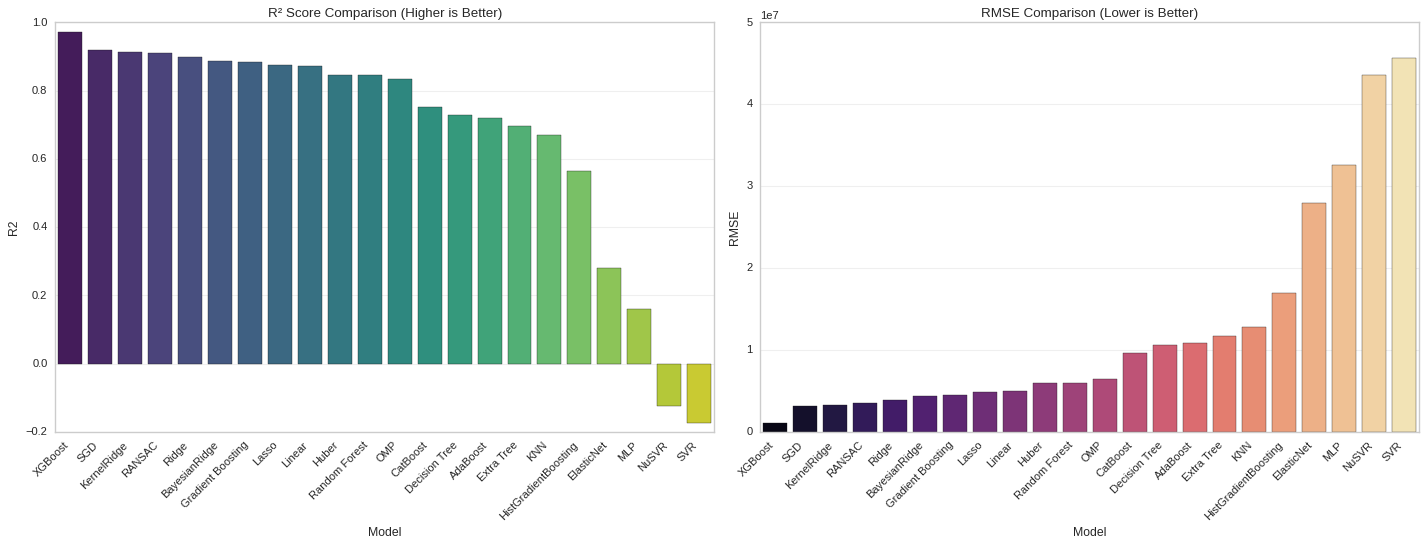

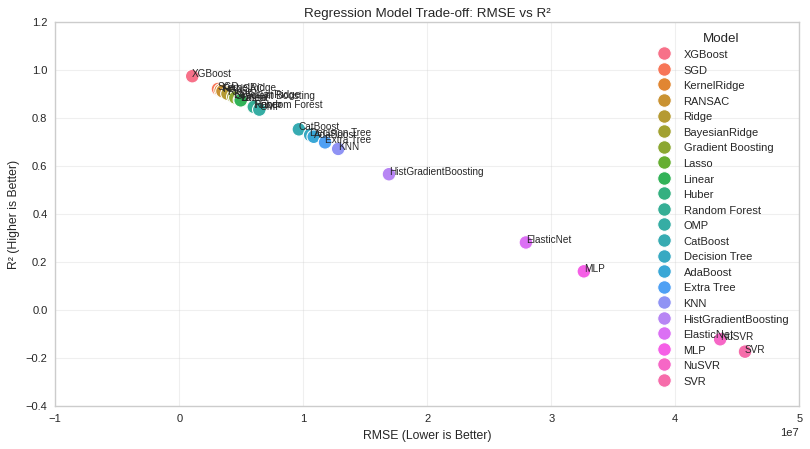

,Model,R2,RMSE
15,XGBoost,0.972890,1.052892e+06
4,SGD,0.919451,3.128350e+06
20,KernelRidge,0.913905,3.343739e+06
6,RANSAC,0.910179,3.488438e+06
1,Ridge,0.899775,3.892508e+06
7,BayesianRidge,0.887508,4.368918e+06
12,Gradient Boosting,0.883414,4.527923e+06
2,Lasso,0.873771,4.902458e+06
0,Linear,0.872293,4.959834e+06
5,Huber,0.845439,6.002812e+06


In [16]:
algo_test(x,y)


Modeli ML modelleriyle eğittik ve R2=% 97 RMSE=1.052892e+06 olarak çok iyi bir sonuç elde ettik. 

###  Test

In [17]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [18]:
for i in range(5):
    ornek = x_test.iloc[[i]]
    gercek = y_test.iloc[i]
    tahmin = xgb.predict(ornek)[0]

    print(f"Gerçek: {gercek} | Tahmin: {tahmin}")

Gerçek: 4978 | Tahmin: 4792.07666015625
Gerçek: 7407 | Tahmin: 7407.0126953125
Gerçek: 2518 | Tahmin: 4045.693359375
Gerçek: 4298 | Tahmin: 4131.197265625
Gerçek: 5394 | Tahmin: 5090.69775390625


In [22]:
import joblib
joblib.dump(xgb, "instagram_reach_model.pkl")

['instagram_reach_model.pkl']

In [1]:
# https://huggingface.co/spaces/fatmasy/InstagramReachRegression

In [2]:
# https://github.com/fatmasy/Instagram-Reach-Analysis-/settings